# Taller 1 - Tópicos Modernos en Criptografía

# Ejercicio 1 — Cifrado Afín

Sea el cifrado afín definido por:

$$
E_{a,b}(x) = ax + b \pmod{26}
$$

donde el alfabeto es el inglés de 26 letras  
$\{A, B, \dots, Z\}$ con la codificación:

$$
A \rightarrow 0,\quad
B \rightarrow 1,\quad
\dots,\quad
Z \rightarrow 25
$$

## a) ¿Para qué valores de \(a\) y \(b\) es posible descifrar?

Partimos del cifrado:

$$
c \equiv ax + b \pmod{26}
$$

Para descifrar, se debe despejar $(x)$:

$$
x \equiv a^{-1}(c - b) \pmod{26}
$$

Por lo tanto, es necesario que exista el inverso multiplicativo de $a$ módulo 26.
Esto ocurre **si y solo si**:

$$
\gcd(a,26) = 1
$$

Como \($26 = 2 \cdot 13$\), los valores de $a$ coprimos con 26 en el conjunto
$\{0,1,\dots,25\}$ son:

$$
a \in \{1,3,5,7,9,11,15,17,19,21,23,25\}
$$

Para el parámetro $b$  no existe restricción adicional, ya que representa
únicamente una suma módulo 26. Por tanto:

$$
b \in \{0,1,2,\dots,25\}
$$

In [266]:
import string
from collections import Counter

ALFABETO = string.ascii_uppercase
M = 26

In [267]:
def euclid(a: int, b: int) -> int:
    while b != 0:
        a, b = b, a % b
    return abs(a)

def egcd(a: int, b: int):
    if b == 0:
        return (a, 1, 0)
    g, x1, y1 = egcd(b, a % b)
    return (g, y1, x1 - (a // b) * y1)

def inverso(a: int, m: int) -> int:
    g, x, _ = egcd(a, m)
    if g != 1:
        raise ValueError("No existe inverso")
    return x % m

In [268]:
a_validos = [a for a in range(M) if euclid(a, M) == 1]
b_validos = list(range(M))

print("Valores válidos de a:", a_validos)
print("Valores válidos de b:", b_validos)

Valores válidos de a: [1, 3, 5, 7, 9, 11, 15, 17, 19, 21, 23, 25]
Valores válidos de b: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## b) ¿Cuántas claves válidas $k=(a,b)$ existen?

Del apartado anterior se tiene que:

- El número de valores válidos para $a$ es $12$.
- El número de valores posibles para $b$ es $26$.

Por lo tanto, el número total de claves válidas es:

$$
|K| = 12 \times 26 = \boxed{312}
$$

In [269]:
total_claves = len(a_validos) * len(b_validos)
print("Número total de claves válidas:", total_claves)

Número total de claves válidas: 312


## c) Criptoanálisis con clave $k=(a,20)$

Se interceptó el siguiente texto cifrado con $b=20$:
OAZUSKHFKHYCXKKGWKZUOQUFKQFACUOOYHOAQPZKOKOOYZYPYXGWKHYOKTUHCWKHFUTKZYCYQPZACUTUGWKKOZUNATURYJHNYHHKWQUHH.

### i) Determinar el valor de $a$

Se realiza un análisis de frecuencia del texto cifrado. La letra que aparece con
mayor frecuencia es **K**.

En español, la letra más frecuente suele ser **E**, por lo que se plantea la
hipótesis:

$$
E \longrightarrow K
$$

Usando la codificación $(A=0,\dots,Z=25)$:

$$
E = 4, \quad K = 10
$$

Sustituyendo en la ecuación del cifrado afín $(c \equiv am + 20 \pmod{26})$, se obtiene:

$$
10 \equiv 4a + 20 \pmod{26}
$$

Restando 20 a ambos lados:

$$
4a \equiv -10 \equiv 16 \pmod{26}
$$

Como $\gcd(4,26)=2$, se divide la congruencia entre 2:

$$
2a \equiv 8 \pmod{13}
$$

El inverso de \(2\) módulo \(13\) es \(7\), ya que:

$$
2 \cdot 7 = 14 \equiv 1 \pmod{13}
$$

Por tanto:

$$
a \equiv 8 \cdot 7 = 56 \equiv 4 \pmod{13}
$$

Esto produce dos soluciones en módulo 26:

$$
a = 4 \quad \text{o} \quad a = 17
$$

Sin embargo, el cifrado solo es descifrable si $\gcd(a,26)=1$. Como:

$$
\gcd(4,26)=2 \quad \text{y} \quad \gcd(17,26)=1
$$

se concluye que:

$$
\boxed{a = 17}
$$

In [270]:
c = (
    "OAZUSKHFKHYCXKKGWKZUOQUFKQFACUOOYHOAQPZKOKOOYZYPYXGWKHYOKTUHCWKHFUTKZYCYQPZA"
    "CUTUGWKKOZUNATURYJHNYHHKWQUHH."
)

b = 20

In [271]:
frecuencias = Counter(ch for ch in c if ch in ALFABETO)
letra_mas_frecuente, _ = frecuencias.most_common(1)[0]

print("Letra más frecuente en el cifrado:", letra_mas_frecuente)

m_E = ord('E') - ord('A')
c_top = ord(letra_mas_frecuente) - ord('A')
rhs = (c_top - b) % M

candidatos_a = [a for a in range(M) if (a * m_E) % M == rhs and euclid(a, M) == 1]
a = candidatos_a[0]

print("Valor de a:", a)

Letra más frecuente en el cifrado: K
Valor de a: 17


### ii) Descifrar el texto y recuperar el mensaje original

Usando la clave $(a,b)=(17,20)$, se obtiene el siguiente texto descifrado
(sin espacios):
SILAGENTENOCREEQUELASMATEMTICASSONSIMPLESESSOLOPORQUENOSEDANCUENTADELOCOMPLICADAQUEESLAVIDAJOHNVONNEUMANN.

In [272]:
def normalizar(texto: str) -> str:
    return texto.upper()

def cifrar_afin(texto: str, a: int, b: int) -> str:
    if euclid(a, M) != 1:
        raise ValueError("a no es invertible módulo 26")
    texto = normalizar(texto)
    res = []
    for ch in texto:
        if ch in ALFABETO:
            m = ord(ch) - ord('A')
            c = (a * m + b) % M
            res.append(chr(c + ord('A')))
        else:
            res.append(ch)
    return "".join(res)

def descifrar_afin(texto: str, a: int, b: int) -> str:
    if euclid(a, M) != 1:
        raise ValueError("a no es invertible módulo 26")
    a_inv = inverso(a, M)
    texto = normalizar(texto)
    res = []
    for ch in texto:
        if ch in ALFABETO:
            c = ord(ch) - ord('A')
            m = (a_inv * (c - b)) % M
            res.append(chr(m + ord('A')))
        else:
            res.append(ch)
    return "".join(res)

In [273]:
m_descifrado = descifrar_afin(c, a, b)
print("Mensaje descifrado sin espacios:")
print(m_descifrado)

Mensaje descifrado sin espacios:
SILAGENTENOCREEQUELASMATEMTICASSONSIMPLESESSOLOPORQUENOSEDANCUENTADELOCOMPLICADAQUEESLAVIDAJOHNVONNEUMANN.


### iii) Explicación del procedimiento utilizado

1. Se contó la frecuencia de letras del texto cifrado.
2. Se identificó la letra más frecuente.
3. Se asumió que dicha letra corresponde a la letra **E**, la más frecuente en español.
4. Se convirtieron las letras a números usando la codificación $(A=0,\ldots,Z=25)$.
5. Se planteó la ecuación del cifrado afín con $(b=20)$ y se resolvió la congruencia
   modular para hallar $a$.
6. Se descartaron los valores de $a$ que no son invertibles módulo 26.
7. Se aplicó la fórmula de descifrado carácter por carácter.

### iv) Mensaje con espacios para hacerlo legible

Agregando los espacios necesarios para una correcta lectura, el mensaje original es:

> **SI LA GENTE NO CREE QUE LAS MATEMÁTICAS SON SIMPLES ES SOLO PORQUE NO SE DAN CUENTA DE LO COMPLICADA QUE ES LA VIDA.  
> JOHN VON NEUMANN.**

# Ejercicio 2 — Cifrado de Hill

Considere el cifrado de Hill sobre $\mathbb{Z}_{26}$ con bloques de tamaño $2$,
definido por:

$$
E_K(x) = xK \pmod{26}
$$

donde $x \in \mathbb{Z}_{26}^2$ es un vector fila y  
$K \in \mathbb{Z}_{26}^{2\times 2}$ es la matriz clave.

Sea la matriz clave:

$$
K =
\begin{pmatrix}
24 & 5 \\
13 & 7
\end{pmatrix}
$$

## a) ¿La matriz $K$ constituye una clave válida para el cifrado de Hill?

Para que una matriz $K$ sea una clave válida en el cifrado de Hill sobre
$\mathbb{Z}_{26}$, es necesario y suficiente que $K$ sea **invertible módulo 26**.

Esto equivale a exigir que su determinante sea coprimo con 26, es decir:

$$
\gcd(\det(K), 26) = 1
$$

Calculamos el determinante de la matriz $K$:

$$
\det(K) = (24)(7) - (5)(13)
$$

$$
\det(K) = 168 - 65 = 103
$$
Reducimos el determinante módulo 26:

$$
103 \equiv 25 \pmod{26}
$$

Ahora verificamos la coprimalidad:

$$
\gcd(25,26) = 1
$$

Como el determinante de $K$ es coprimo con 26, la matriz $K$ es invertible
módulo 26.

Por lo tanto, se concluye que:

$$
\boxed{\text{La matriz } K \text{ constituye una clave válida para el cifrado de Hill sobre } \mathbb{Z}_{26}.}
$$

In [274]:
import numpy as np

M = 26  # módulo

# ---- mismas utilidades (euclid + inverso) estilo ejercicio 1 ----
def euclid(a: int, b: int) -> int:
    a, b = abs(a), abs(b)
    while b != 0:
        a, b = b, a % b
    return a

def egcd(a: int, b: int):
    if b == 0:
        return (a, 1, 0)
    g, x1, y1 = egcd(b, a % b)
    x = y1
    y = x1 - (a // b) * y1
    return (g, x, y)

def inverso(a: int, m: int) -> int:
    g, x, _ = egcd(a, m)
    if g != 1:
        raise ValueError(f"No existe inverso: gcd({a},{m})={g}")
    return x % m

# ---- matriz clave dada ----
K = np.array([[24, 5],
              [13, 7]], dtype=int)

# ---- determinante entero de una 2x2: ad - bc ----
a, b = K[0,0], K[0,1]
c, d = K[1,0], K[1,1]
detK = a*d - b*c
detK_mod = detK % M

print("Matriz K:\n", K)
print("\nDet(K) =", detK)
print("Det(K) mod 26 =", detK_mod)
print("gcd(Det(K), 26) =", euclid(detK_mod, M))

# ---- verificación de validez (invertible mod 26) ----
if euclid(detK_mod, M) != 1:
    print("\n K NO es clave válida (no es invertible módulo 26).")
else:
    print("\n K es clave válida (es invertible módulo 26).")


Matriz K:
 [[24  5]
 [13  7]]

Det(K) = 103
Det(K) mod 26 = 25
gcd(Det(K), 26) = 1

 K es clave válida (es invertible módulo 26).


## b) Descifrado de los textos interceptados

Se interceptaron los siguientes bloques cifrados (tamaño 2), generados con la matriz clave:

$$
K=
\begin{pmatrix}
24 & 5\\
13 & 7
\end{pmatrix}
$$

Los textos cifrados interceptados son:

$$
c=(M,L), \qquad c'=(R,E)
$$

Usando la codificación $A=0,\ldots,Z=25$ y la regla de descifrado del cifrado de Hill:

$$
m \equiv cK^{-1} \pmod{26},
$$

se obtiene:

- Para $c=(M,L)$, el bloque en claro es:

$$
m = (H,E)
$$

- Para $c'=(R,E)$, el bloque en claro es:

$$
m' = (L,P)
$$

Por lo tanto, los textos descifrados son:

$$
c=(M,L)\ \longrightarrow\ \textbf{HE},
\qquad
c'=(R,E)\ \longrightarrow\ \textbf{LP}.
$$

In [275]:
import string
ALFABETO = string.ascii_uppercase
M = 26

def normalizar(texto: str) -> str:
    return "".join([c for c in texto.upper() if c in ALFABETO])

def inv_matriz_mod_np(K, mod=26):
    K = np.array(K, dtype=int) % mod
    n = K.shape[0]
    if K.shape[1] != n:
        raise ValueError("K debe ser cuadrada (j×j).")

    if n != 2:
        raise ValueError("Este parche solo implementa la inversa para 2x2 (como pide el ejercicio).")

    a, b = int(K[0,0]), int(K[0,1])
    c, d = int(K[1,0]), int(K[1,1])

    det = (a*d - b*c) % mod
    if euclid(det, mod) != 1:
        raise ValueError("La matriz no es invertible mod 26.")

    det_inv = inverso(det, mod)  

    adj = np.array([[ d, -b],
                    [-c,  a]], dtype=int) % mod

    return (det_inv * adj) % mod


def hill_cifrar(texto: str, K):
    K = np.array(K, dtype=int) % M
    j = K.shape[0]

    P = normalizar(texto)
    P += "X" * ((-len(P)) % j)   # padding a múltiplo de j

    nums = np.array([ord(c) - 65 for c in P], dtype=int)
    bloques = nums.reshape(-1, j)      # vectores fila
    cif = (bloques @ K) % M            # c = mK

    return "".join(chr(x + 65) for x in cif.reshape(-1))

def hill_descifrar(texto_cifrado: str, K):
    K = np.array(K, dtype=int) % M
    j = K.shape[0]

    C = normalizar(texto_cifrado)
    if len(C) % j != 0:
        raise ValueError("Longitud del cifrado no es múltiplo de j.")

    K_inv = inv_matriz_mod_np(K, M)

    nums = np.array([ord(c) - 65 for c in C], dtype=int)
    bloques = nums.reshape(-1, j)
    pla = (bloques @ K_inv) % M         # m = cK^{-1}

    return "".join(chr(x + 65) for x in pla.reshape(-1))


In [276]:
K = [[24, 5],
     [13, 7]]

c  = "ML"   # (M,L)
cp = "RE"   # (R,E)

print("K_inv mod 26:\n", inv_matriz_mod_np(K, 26))

m  = hill_descifrar(c, K)
mp = hill_descifrar(cp, K)

print("c  =", (c[0], c[1]), "->", m)
print("c' =", (cp[0], cp[1]), "->", mp)

K_inv mod 26:
 [[19  5]
 [13  2]]
c  = ('M', 'L') -> HE
c' = ('R', 'E') -> LP


## c) Ataque de texto claro conocido

Se considera un escenario de **ataque de texto claro conocido**, en el cual el
atacante dispone de pares $(m_i, c_i)$ (texto claro, texto cifrado), pero
desconoce la matriz clave $K$. Cada par satisface:

$$
c_i \equiv m_i K \pmod{26},
$$

donde \($m_i \in \mathbb{Z}_{26}^{1\times 2}$\) y \($c_i \in \mathbb{Z}_{26}^{1\times 2}$\).

---

### a) Modelación matemática del problema

Si el atacante dispone de $t$ pares conocidos $(m_i, c_i)$, estos pueden
agruparse en matrices:

$$
M =
\begin{pmatrix}
m_1 \\
m_2 \\
\vdots \\
m_t
\end{pmatrix}
\in \mathbb{Z}_{26}^{t\times 2},
\qquad
C =
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_t
\end{pmatrix}
\in \mathbb{Z}_{26}^{t\times 2}.
$$

El sistema completo queda modelado como:

$$
C \equiv M K \pmod{26}.
$$

Por lo tanto, el problema de recuperar la matriz $K$ se reduce a resolver un
**sistema lineal modular**. Si existe una submatriz $2\times 2$ de $M$ que sea
invertible módulo 26, entonces la matriz clave se obtiene como:

$$
K \equiv M^{-1} C \pmod{26}.
$$

---

### b) Número mínimo de pares necesarios y condición

La matriz $K$ es de tamaño $2\times 2$, por lo que contiene **cuatro
incógnitas**. Cada par $(m_i, c_i)$ proporciona **dos ecuaciones lineales**,
una por cada componente del vector $c_i$. En consecuencia, el número mínimo de
pares necesarios es:

$$
\boxed{2 \text{ pares } (m_i, c_i)}.
$$

Estos dos pares deben satisfacer una condición adicional: los vectores de texto
claro $m_1$ y $m_2$ deben ser **linealmente independientes** en
$\mathbb{Z}_{26}^2$. Equivalentemente, la matriz

$$
M =
\begin{pmatrix}
m_1 \\
m_2
\end{pmatrix}
$$

debe ser invertible módulo 26, lo que ocurre si y solo si:

$$
\boxed{\gcd(\det(M), 26) = 1}.
$$

Cuando esta condición se cumple, la matriz clave $K$ puede recuperarse de forma
única mediante:

$$
K \equiv M^{-1} C \pmod{26}.
$$

# Ejercicio 3 - Vignere

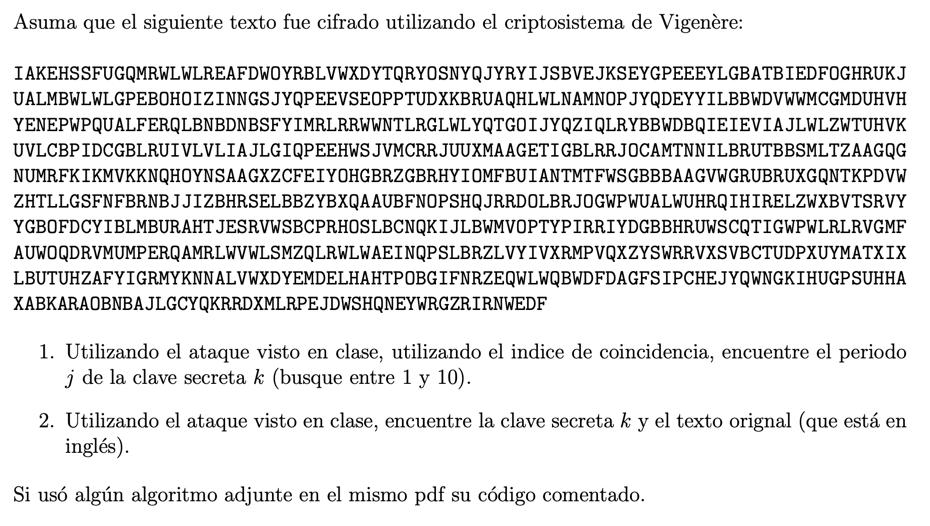

In [277]:
# Texto original
abecedario = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8,
    'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16,
    'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24,
    'Z': 25
}

inv_abecedario = {idx: letra for letra, idx in abecedario.items()}

c = "IAKEHSSFUGQMRWLWLREAFDWOYRBLVWXDYTQRYOSNYQJYRYIJSBVEJKSEYGPEEEYLGBATBIEDFOGHRUKJUALMBWLWLGPEBOHOIZINNGSJYQPEEVSEOPPTUDXKBRUAQHLWLNAMN" + "OPJYQDEYYILBBWDVWWMCGMDUHVHYENEPWPQUALFERQLBNBDNBSFYIMRLRRWWNTLRGLWLYQTGOIJYQZIQLRYBBWDBQIEIEVIAJLWLZWTUHVKUVLCBPIDCGBLRUIVLVLIAJLGIQPEE" + "HWSJVMCRRJUUXMAAGETIGBLRRJOCAMTNNILBRUTBBSMLTZAAGQGNUMRFKIKMVKKNQHOYNSAAGXZCFEIYOHGBRZGBRHYIOMFBUIANTMTFWSGBBBAAGVWGRUBRUXGQNTKPDVWZHTLL" + "GSFNFBRNBJJIZBHRSELBBZYBXQAAUBFNOPSHQJRRDOLBRJOGWPWUALWUHRQIHIRELZWXBVTSRVYYGBOFDCYIBLMBURAHTJESRVWSBCPRHOSLBCNQKIJLBWMVOPTYPIRRIYDGBBHR" + "UWSCQTIGWPWLRLRVGMFAUWOQDRVMUMPERQAMRLWVWLSMZQLRWLWAEINQPSLBRZLVYIVXRMPVQXZYSWRRVXSVBCTUDPXUYMATXIXLBUTUHZAFYIGRMYKNNALVWXDYEMDELHAHTPOB" + "GIFNRZEQWLWQBWDFDAGFSIPCHEJYQWNGKIHUGPSUHHAXABKARAOBNBAJLGCYQKRRDXMLRPEJDWSHQNEYWRGZRIRNWEDF"

In [278]:
# IC del español e inglés - sacados de internet
IC_eng = 0.0667

In [279]:
# IC del texto original - se calcula con la fórmula del índice de coincidencia, que es la siguiente:
from collections import Counter
def index_of_coincidence(text: str) -> float:
    n = len(text)
    if n <= 1:
        return 1.0  # Si el texto está vacío, el índice de coincidencia es 1 por definición
    frequency = Counter(text)
    ic = sum(count * (count - 1) for count in frequency.values()) / (n * (n - 1))
    return ic
ic_original = index_of_coincidence(c)
print(f"Índice de coincidencia del texto original: {ic_original:.4f}")

Índice de coincidencia del texto original: 0.0430


In [280]:
# Para determinar len(K), es necesario dividir el string original en grupos de longitud n, y calcular el índice de coincidencia para cada grupo. El valor de n que produce un índice de coincidencia cercano al del español (0.0778) es el valor de len(K).

import textwrap

# Probar con n desde 1 hasta 10, como dice el enunciado

group_set = {}

for n in range(1, 11):
    # Dividir el string original en grupos de longitud n
    groups = textwrap.wrap(c, n)
    group_set[n] = groups
    if n > 7: print(f"Grupos para n={n}:\n{groups}") # Imprimir los grupos para n > 5 para verificar que se están formando correctamente


Grupos para n=8:
['IAKEHSSF', 'UGQMRWLW', 'LREAFDWO', 'YRBLVWXD', 'YTQRYOSN', 'YQJYRYIJ', 'SBVEJKSE', 'YGPEEEYL', 'GBATBIED', 'FOGHRUKJ', 'UALMBWLW', 'LGPEBOHO', 'IZINNGSJ', 'YQPEEVSE', 'OPPTUDXK', 'BRUAQHLW', 'LNAMNOPJ', 'YQDEYYIL', 'BBWDVWWM', 'CGMDUHVH', 'YENEPWPQ', 'UALFERQL', 'BNBDNBSF', 'YIMRLRRW', 'WNTLRGLW', 'LYQTGOIJ', 'YQZIQLRY', 'BBWDBQIE', 'IEVIAJLW', 'LZWTUHVK', 'UVLCBPID', 'CGBLRUIV', 'LVLIAJLG', 'IQPEEHWS', 'JVMCRRJU', 'UXMAAGET', 'IGBLRRJO', 'CAMTNNIL', 'BRUTBBSM', 'LTZAAGQG', 'NUMRFKIK', 'MVKKNQHO', 'YNSAAGXZ', 'CFEIYOHG', 'BRZGBRHY', 'IOMFBUIA', 'NTMTFWSG', 'BBBAAGVW', 'GRUBRUXG', 'QNTKPDVW', 'ZHTLLGSF', 'NFBRNBJJ', 'IZBHRSEL', 'BBZYBXQA', 'AUBFNOPS', 'HQJRRDOL', 'BRJOGWPW', 'UALWUHRQ', 'IHIRELZW', 'XBVTSRVY', 'YGBOFDCY', 'IBLMBURA', 'HTJESRVW', 'SBCPRHOS', 'LBCNQKIJ', 'LBWMVOPT', 'YPIRRIYD', 'GBBHRUWS', 'CQTIGWPW', 'LRLRVGMF', 'AUWOQDRV', 'MUMPERQA', 'MRLWVWLS', 'MZQLRWLW', 'AEINQPSL', 'BRZLVYIV', 'XRMPVQXZ', 'YSWRRVXS', 'VBCTUDPX', 'UYMATXIX', 'LBUTUHZA', 'FYIGRMYK'

In [281]:
# Sacar las columnas de cada grupo para calcular el índice de coincidencia de cada columna

ic_avg = {}

for n, groups in group_set.items():
    ic_col_list= []
    print(f"\nCalculando índice de coincidencia para n={n}...")
    columns = [''.join(group[i] for group in groups if i < len(group)) for i in range(n)]
    for i, column in enumerate(columns):
        ic_column = index_of_coincidence(column)
        ic_col_list.append(ic_column)
        print(f"Columna {i+1} - Índice de coincidencia: {ic_column:.4f}")
    ic_avg[n] = sum(ic_col_list) / len(ic_col_list)
    print(f"Promedio del índice de coincidencia para n={n}: {ic_avg[n]:.4f}")


Calculando índice de coincidencia para n=1...
Columna 1 - Índice de coincidencia: 0.0430
Promedio del índice de coincidencia para n=1: 0.0430

Calculando índice de coincidencia para n=2...
Columna 1 - Índice de coincidencia: 0.0477
Columna 2 - Índice de coincidencia: 0.0459
Promedio del índice de coincidencia para n=2: 0.0468

Calculando índice de coincidencia para n=3...
Columna 1 - Índice de coincidencia: 0.0419
Columna 2 - Índice de coincidencia: 0.0419
Columna 3 - Índice de coincidencia: 0.0449
Promedio del índice de coincidencia para n=3: 0.0429

Calculando índice de coincidencia para n=4...
Columna 1 - Índice de coincidencia: 0.0595
Columna 2 - Índice de coincidencia: 0.0558
Columna 3 - Índice de coincidencia: 0.0524
Columna 4 - Índice de coincidencia: 0.0484
Promedio del índice de coincidencia para n=4: 0.0540

Calculando índice de coincidencia para n=5...
Columna 1 - Índice de coincidencia: 0.0398
Columna 2 - Índice de coincidencia: 0.0426
Columna 3 - Índice de coincidencia: 0

In [282]:
# Encontrar el N con mayor similitud al índice de coincidencia al del inglés (0.0667)
closest_n_eng = min(ic_avg, key=lambda x: abs(ic_avg[x] - IC_eng))

print(f"El valor de n que produce un índice de coincidencia promedio más cercano al del inglés (0.0667) es: {closest_n_eng} con un índice de coincidencia promedio de {ic_avg[closest_n_eng]:.4f}")

key_length = closest_n_eng

El valor de n que produce un índice de coincidencia promedio más cercano al del inglés (0.0667) es: 8 con un índice de coincidencia promedio de 0.0685


In [283]:
def split_by_key_position(ciphertext, m):
    g = ['' for _ in range(m)]
    for i, ci in enumerate(ciphertext):
        if ci.isalpha():
            g[i % m] += ci.upper()
    return g

In [284]:
# Frecuencia de las letras en inglés
import math

EN_FREQ = {
    'A':0.08167,'B':0.01492,'C':0.02782,'D':0.04253,'E':0.12702,
    'F':0.02228,'G':0.02015,'H':0.06094,'I':0.06966,'J':0.00153,
    'K':0.00772,'L':0.04025,'M':0.02406,'N':0.06749,'O':0.07507,
    'P':0.01929,'Q':0.00095,'R':0.05987,'S':0.06327,'T':0.09056,
    'U':0.02758,'V':0.00978,'W':0.02360,'X':0.00150,'Y':0.01974,
    'Z':0.00074
}

In [285]:
from collections import Counter

def decrypt_group_with_shift(group, shift):
    # Apply Vigenère/Caesar decryption with trial shift s
    decrypted = []
    for c in group:
        y = abecedario[c]
        p = (y - shift) % 26
        decrypted.append(inv_abecedario[p])
    return decrypted


def empirical_freq(letters):
    N = len(letters)
    counts = Counter(letters)
    return {L: counts.get(L, 0)/N for L in EN_FREQ}  # aligned support

In [286]:
def squared_distance(group, shift):
    # descifrar
    decrypted = decrypt_group_with_shift(group, shift)

    # distr. empirica p^gorro_l(s)
    p_hat = empirical_freq(decrypted)

    # calcular d_i(s) = suma( (p^gorro_l(s) - q_l)^2 )
    d = 0.0
    for L in EN_FREQ:
        d += (p_hat[L] - EN_FREQ[L])**2

    return d

In [291]:
def best_shift_for_group(group):
    # retornar el minimo de distancia, probar en cada shift
    return min(
        range(26),
        key=lambda s: squared_distance(group, s)
    )

In [288]:
def recover_key(ciphertext, m):
    groups = split_by_key_position(ciphertext, m)
    key = ""

    for group in groups:
        s = best_shift_for_group(group)
        key += inv_abecedario[s]

    return key

In [289]:
key = recover_key(c, key_length)
print(f"La clave secreta es: {key}")

La clave secreta es: UNIANDES


In [290]:
# Descifrar el texto con la clave K encontrada
def vigenere_decrypt(ciphertext: str, key: str) -> str:
    plaintext = ""
    key_len = len(key)
    key_vals = [abecedario[k] for k in key]
    key_idx = 0
    for char in ciphertext:
        if char in abecedario:
            y = abecedario[char]
            x = (y - key_vals[key_idx % key_len]) % 26
            plaintext += inv_abecedario[x]
            key_idx += 1
        else:
            plaintext += char
    return plaintext

mensaje_descifrado = vigenere_decrypt(c, key)
print(f"Mensaje descifrado:\n{mensaje_descifrado}")

Mensaje descifrado:
ONCEUPONATIMETHEREWASASWEETLITTLEGIRLLOVEDBYEVERYONEWHOMETHERBUTMOSTOFALLBYHERGRANDMOTHERTHEOLDWOMANADOREDHERSOMUCHTHATSHEMADEHERASMALLREDVELVETHOODITSUITEDHERPERFECTLYANDFROMTHATDAYONEVERYONECALLEDHERLITTLEREDRIDINGHOODONEMORNINGHERMOTHERSAIDCOMELITTLEREDRIDINGHOODHERESAPIECEOFCAKEANDABOTTLEOFWINETAKETHEMTOYOURGRANDMOTHERSHESSICKANDWEAKANDTHISWILLDOHERGOODGOBEFOREITGETSTOOHOTANDREMEMBERTOWALKCAREFULLYDONTSTRAYFROMTHEPATHORYOUMIGHTFALLANDBREAKTHEBOTTLEANDWHENYOUARRIVEDONTFORGETTOSAYGOODMORNINGBEFOREYOUPEEKAROUNDHERROOMILLBECAREFULMOTHERSAIDLITTLEREDRIDINGHOODANDSHEPROMISEDWITHASMILETHEGRANDMOTHERLIVEDDEEPINTHEFORESTABOUTHALFALEAGUEFROMTHEVILLAGEJUSTASLITTLEREDRIDINGHOODENTEREDTHEWOODSAWOLFAPPEAREDONTHEPATHSHEDIDNTKNOWWHATAWICKEDCREATUREHEWASANDFELTNOFEARATALL


# Ejercicio 4 - Colisiones en padding
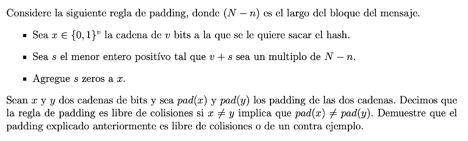

Sea $b \coloneqq N - n$

$$
x = \{0,1\}^v \;\to\; v = |x|
$$

$$
\mathrm{pad}(x) = x 0^S \;\to\; S = \min \bigl( s \in \mathbb{Z}_{>0} \;:\; v + s \equiv 0 \pmod{b} \bigr)
$$

$$
\forall x,y \in \{0,1\}^* \;:\; x \ne y \implies \mathrm{pad}(x) \ne \mathrm{pad}(y)
$$

Por contraejemplo:

$$
x = 1 0^{(b-1)}, \quad y = 1 0^{(b-2)}
$$

$$
\mathrm{pad}(x) = 1 0^{(b-1)} 0 = 1 0^b
$$

$$
\mathrm{pad}(y) = 1 0^{(b-2)} 00 = 1 0^b
$$

$$
x \ne y \;\land\; \mathrm{pad}(x) = \mathrm{pad}(y)
$$
